# 05 · Stability Screening and Correlation Pruning

Layer 4 of the feature-selection funnel. Development sample only.

**Step 1 — stability**

| Condition | Meaning | Action |
|---|---|---|
| train IV < 0.02 | not predictive | drop |
| WOE consistency < 0.7 | **relationship drift** — the risk pattern changed | drop |
| valid IV < 50% of train IV | discrimination decay | drop |
| PSI > 0.25 **and** WOE consistency ≥ 0.9 | distribution drift only — the relationship is intact | **keep**, flag for monitoring |

An **adversarial validation** model (LightGBM separating train from valid rows) highlights the features that differ
most between the two periods; top features not already covered above are listed for manual review.

**Step 2 — correlation (Spearman on a 100k sample)**
- GBDT pool: |ρ| > 0.95 treated as duplicates, keep the higher-IV feature
- Scorecard pool: drop GBDT-only and high-cardinality (> 50) categorical features, then |ρ| > 0.7; when two IVs are
  within 10%, keep the one with the lower PSI

**Outputs:** `05_feature_selection.parquet/.csv`, `05_gbdt_features.json`, `05_scorecard_candidates.json`

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))

import gc
import json
import time
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")   # LightGBM 3.x categorical-feature notices

from hcrisk.config import RES_DIR, SEED, TRAIN_END, VALID_END, savefig

q = pl.read_parquet(RES_DIR / "03_feature_quality.parquet")
iv = pl.read_parquet(RES_DIR / "04_iv.parquet").join(q.select("feature", "n_unique"), on="feature", how="left")
print(f"features entering this step: {iv.height}")

features entering this step: 438


## 1. Stability rules

In [2]:
IV_MIN, WOE_MIN, DECAY, PSI_HIGH, WOE_STABLE = 0.02, 0.7, 0.5, 0.25, 0.9
sel = iv.with_columns(
    pl.when(pl.col("iv_train") < IV_MIN).then(pl.lit("IV < 0.02"))
      .when(pl.col("woe_consistency") < WOE_MIN).then(pl.lit("relationship drift (WOE consistency < 0.7)"))
      .when(pl.col("iv_valid") < DECAY * pl.col("iv_train")).then(pl.lit("IV decay (valid IV < 50% of train)"))
      .otherwise(None).alias("drop_reason"),
    ((pl.col("psi_train_valid") > PSI_HIGH) & (pl.col("woe_consistency") >= WOE_STABLE)).alias("monitor"),
)
display(sel.group_by("drop_reason").len().sort("len", descending=True))
stable = sel.filter(pl.col("drop_reason").is_null())
print(f"stable: {stable.height} | of which 'distribution drift only' (monitor): {stable['monitor'].sum()} | "
      f"WOE consistency not computable (too few bins): {stable['woe_consistency'].is_null().sum()}")
display(sel.filter(pl.col("drop_reason").str.contains("drift|decay"))
           .select("table", "feature", "iv_train", "iv_valid", "psi_train_valid", "woe_consistency", "drop_reason")
           .sort("iv_train", descending=True))

drop_reason,len
str,u32
null,235
"""IV < 0.02""",189
"""IV decay (valid IV < 50% of tr…",11
"""relationship drift (WOE consis…",3


stable: 235 | of which 'distribution drift only' (monitor): 48 | WOE consistency not computable (too few bins): 4


table,feature,iv_train,iv_valid,psi_train_valid,woe_consistency,drop_reason
str,str,f64,f64,f64,f64,str
"""depth0""","""pmtaverage_3A""",0.090501,2.7069e-7,1.848798,null,"""IV decay (valid IV < 50% of tr…"
"""depth0""","""pmtnum_254L""",0.064459,0.031728,0.185694,0.922172,"""IV decay (valid IV < 50% of tr…"
"""depth0""","""assignmentdate_238D""",0.062841,2.7069e-7,1.757566,null,"""IV decay (valid IV < 50% of tr…"
"""depth0""","""pmtcount_693L""",0.055193,2.4377e-8,2.221232,null,"""IV decay (valid IV < 50% of tr…"
"""credit_bureau_a_2""","""pmts_year_1139T_yrsago__max""",0.042858,0.031034,7.187719,0.461277,"""relationship drift (WOE consis…"
…,…,…,…,…,…,…
"""person_1""","""empl_industry_691L__first""",0.029925,0.012183,0.005512,0.874888,"""IV decay (valid IV < 50% of tr…"
"""person_1""","""empladdr_district_926M__first""",0.026492,0.00669,0.006051,0.811103,"""IV decay (valid IV < 50% of tr…"
"""person_1""","""empl_industry_691L__nuniq""",0.021718,0.003135,0.005443,null,"""IV decay (valid IV < 50% of tr…"


## 2. Adversarial validation
A high AUC is expected in the full data (credit-bureau fields were expanded around week 22, so missingness differs
between periods). Focus on highly ranked features that are **not** flagged as `monitor`.

In [3]:
feats = stable["feature"].to_list()
d = pl.scan_parquet(RES_DIR / "model_data.parquet").filter(pl.col("WEEK_NUM") <= VALID_END).select(["WEEK_NUM"] + feats).collect()
d_tr, d_va = d.filter(pl.col("WEEK_NUM") <= TRAIN_END), d.filter(pl.col("WEEK_NUM") > TRAIN_END)
d = pl.concat([d_tr.sample(n=min(150_000, d_tr.height), seed=1), d_va.sample(n=min(150_000, d_va.height), seed=1)])
y_adv = (d["WEEK_NUM"] > TRAIN_END).to_numpy().astype(int)
X = d.drop("WEEK_NUM").with_columns(pl.col(pl.Boolean).cast(pl.Float32)).to_pandas()
for c in X.columns:
    if not pd.api.types.is_numeric_dtype(X[c]):
        X[c] = X[c].astype("category")
del d, d_tr, d_va; _ = gc.collect()

tr_idx = np.random.default_rng(SEED).random(len(X)) < 0.7
adv = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=31, min_child_samples=200,
                         subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1)
adv.fit(X[tr_idx], y_adv[tr_idx])
print(f"adversarial AUC (train vs valid rows): {roc_auc_score(y_adv[~tr_idx], adv.predict_proba(X[~tr_idx])[:, 1]):.3f}")

imp = pl.DataFrame({"feature": X.columns.tolist(), "adv_gain": adv.booster_.feature_importance(importance_type="gain")})
imp = (imp.with_columns((pl.col("adv_gain") / pl.col("adv_gain").sum()).round(4).alias("adv_share"))
          .sort("adv_share", descending=True).with_row_index("adv_rank", offset=1))
stable = stable.join(imp.select("feature", "adv_rank", "adv_share"), on="feature", how="left")
display(stable.sort("adv_rank").head(20)
              .select("adv_rank", "adv_share", "table", "feature", "iv_train", "psi_train_valid", "woe_consistency", "monitor"))
print("top-20 adversarial features not flagged as 'monitor' (manual review, not dropped):")
display(stable.filter((pl.col("adv_rank") <= 20) & ~pl.col("monitor")).select("adv_rank", "feature", "iv_train", "iv_valid", "psi_train_valid"))
del X, adv; _ = gc.collect()

adversarial AUC (train vs valid rows): 0.999


adv_rank,adv_share,table,feature,iv_train,psi_train_valid,woe_consistency,monitor
u32,f64,str,str,f64,f64,f64,bool
1,0.2362,"""credit_bureau_a_1""","""dpdmaxdateyear_596T_yrsago__ma…",0.197487,6.665675,0.920452,true
2,0.2305,"""depth0""","""numinstmatpaidtearly2d_4499204…",0.050407,1.208403,0.979824,true
3,0.1764,"""credit_bureau_a_1""","""overdueamountmaxdateyear_2T_yr…",0.137486,6.774869,0.999528,true
4,0.1207,"""depth0""","""daysoverduetolerancedd_3976961…",0.216544,0.001836,0.990108,false
5,0.0471,"""credit_bureau_a_1""","""credit_bureau_a_1__cnt""",0.022862,0.967149,0.894029,false
…,…,…,…,…,…,…,…
16,0.0057,"""depth0""","""numinstpaidearly_338L""",0.115496,0.000978,0.981179,false
17,0.0054,"""person_1""","""contaddr_district_15M__first""",0.029724,0.003489,0.881859,false
18,0.0052,"""credit_bureau_a_1""","""dpdmaxdateyear_596T_yrsago__me…",0.22707,1.071862,0.951985,true


top-20 adversarial features not flagged as 'monitor' (manual review, not dropped):


adv_rank,feature,iv_train,iv_valid,psi_train_valid
u32,str,f64,f64,f64
15,"""avgdbddpdlast24m_3658932P""",0.224944,0.23094,0.001095
4,"""daysoverduetolerancedd_3976961…",0.216544,0.223062,0.001836
10,"""monthsannuity_845L""",0.040575,0.041161,0.002118
16,"""numinstpaidearly_338L""",0.115496,0.11594,0.000978
5,"""credit_bureau_a_1__cnt""",0.022862,0.024505,0.967149
11,"""credit_bureau_a_2__cnt""",0.029206,0.050303,0.192913
17,"""contaddr_district_15M__first""",0.029724,0.054045,0.003489
12,"""empl_employedfrom_271D__max""",0.071808,0.047296,0.027218
19,"""registaddr_district_1083M__fir…",0.034728,0.062818,0.003138


## 3. Correlation matrix
Rank-transform each column once, then Pearson with pairwise-complete observations — equivalent to Spearman and
~10× faster than `DataFrame.corr(method="spearman")`. Categorical features are not included and are kept.

In [4]:
num_feats = [r["feature"] for r in stable.iter_rows(named=True) if r["dtype"] != "String"]
samp = pl.scan_parquet(RES_DIR / "model_data.parquet").filter(pl.col("WEEK_NUM") <= VALID_END).select(num_feats).collect()
samp = samp.sample(n=min(100_000, samp.height), seed=7)
t0 = time.time()
corr = samp.with_columns(pl.col(pl.Boolean).cast(pl.Float32)).to_pandas().astype("float64").rank().corr(min_periods=1000).abs()
print(f"correlation matrix {corr.shape}, {time.time() - t0:.0f}s")
del samp; _ = gc.collect()


def greedy_select(cands, threshold, prefer_low_psi=False):
    """Greedy selection by descending IV; drop a feature if |rho| with an already selected one exceeds the threshold.
    With prefer_low_psi: if it conflicts with exactly one selected feature whose IV is within 10%, keep the lower-PSI one."""
    info = {r["feature"]: r for r in cands.iter_rows(named=True)}
    chosen, reason = [], {}
    for f in cands.sort("iv_train", descending=True)["feature"].to_list():
        if f not in corr.index:
            chosen.append(f); continue
        conflicts = [s for s in chosen if s in corr.index and corr.at[f, s] > threshold]
        if not conflicts:
            chosen.append(f); continue
        if prefer_low_psi and len(conflicts) == 1:
            s = conflicts[0]
            close = (info[s]["iv_train"] - info[f]["iv_train"]) / info[s]["iv_train"] < 0.10
            others_ok = all(corr.at[f, o] <= threshold for o in chosen if o != s and o in corr.index)
            if close and others_ok and info[f]["psi_train_valid"] < info[s]["psi_train_valid"]:
                chosen[chosen.index(s)] = f
                reason[s] = f"correlated with {f} (similar IV, lower PSI kept)"
                continue
        reason[f] = f"correlated with {conflicts[0]} (|rho| = {corr.at[f, conflicts[0]]:.2f})"
    return chosen, reason

correlation matrix (207, 207), 17s


## 4. Feature pools

In [5]:
gbdt, gbdt_reason = greedy_select(stable, 0.95)
sc_base = stable.filter((pl.col("use") == "all") & pl.col("feature").is_in(gbdt)
                        & ~((pl.col("dtype") == "String") & (pl.col("n_unique") > 50)))
sc, sc_reason = greedy_select(sc_base, 0.7, prefer_low_psi=True)
print(f"GBDT pool: {len(gbdt)} | scorecard candidates: {len(sc)}")

res = sel.join(stable.select("feature", "adv_rank", "adv_share"), on="feature", how="left").with_columns(
    pl.col("feature").is_in(gbdt).alias("in_gbdt"), pl.col("feature").is_in(sc).alias("in_scorecard"),
    pl.col("feature").replace_strict(gbdt_reason, default=None).alias("gbdt_corr_reason"),
    pl.col("feature").replace_strict(sc_reason, default=None).alias("sc_corr_reason"))
display(res.filter(pl.col("in_scorecard")).sort("iv_train", descending=True)
           .select("table", "feature", "dtype", "iv_train", "iv_valid", "psi_train_valid", "woe_consistency", "monitor"))

GBDT pool: 172 | scorecard candidates: 93


table,feature,dtype,iv_train,iv_valid,psi_train_valid,woe_consistency,monitor
str,str,str,f64,f64,f64,f64,bool
"""depth0""","""avgdpdtolclosure24_3658938P""","""Float32""",0.301756,0.310654,0.000168,0.989245,false
"""credit_bureau_a_2""","""pmts_dpd_1073P__mean""","""Float32""",0.282238,0.280403,0.019008,0.988212,false
"""depth0""","""pctinstlsallpaidlate1d_3546856…","""Float32""",0.26707,0.291717,0.000257,0.992884,false
"""applprev_1""","""maxdpdtolerance_577P__mean""","""Float32""",0.262392,0.298071,0.000562,0.988349,false
"""depth0""","""maxdbddpdtollast12m_3658940P""","""Float32""",0.243683,0.264451,0.001711,0.990844,false
…,…,…,…,…,…,…,…
"""credit_bureau_a_1""","""description_351M__first""","""String""",0.021028,0.01682,0.094198,0.96859,false
"""applprev_1""","""isbidproduct_390L__mean""","""Float32""",0.020998,0.038056,0.001379,0.982343,false
"""applprev_1""","""dtlastpmtallstes_3545839D__min""","""Float32""",0.020779,0.033513,0.036328,0.896448,false


## 5. Feature-selection funnel

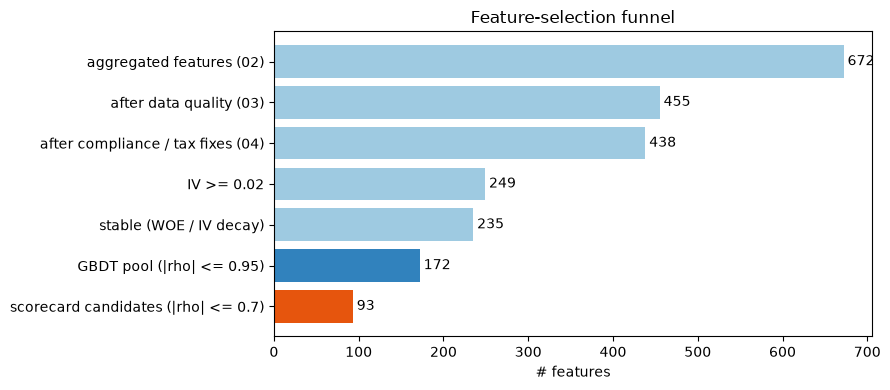

saved: 05_feature_selection.parquet/.csv, 05_gbdt_features.json, 05_scorecard_candidates.json


In [6]:
stages = [("aggregated features (02)", q.height), ("after data quality (03)", q.filter(pl.col("drop_reason").is_null()).height),
          ("after compliance / tax fixes (04)", iv.height), ("IV >= 0.02", sel.filter(pl.col("iv_train") >= IV_MIN).height),
          ("stable (WOE / IV decay)", stable.height), ("GBDT pool (|rho| <= 0.95)", len(gbdt)),
          ("scorecard candidates (|rho| <= 0.7)", len(sc))]
fig, ax = plt.subplots(figsize=(9, 4))
labels, vals = zip(*stages)
ax.barh(range(len(vals))[::-1], vals, color=["#9ecae1"] * 5 + ["#3182bd", "#e6550d"])
ax.set_yticks(range(len(vals))[::-1]); ax.set_yticklabels(labels)
for i, v in enumerate(vals):
    ax.text(v, len(vals) - 1 - i, f" {v}", va="center")
ax.set_xlabel("# features"); ax.set_title("Feature-selection funnel")
plt.tight_layout(); savefig(fig, "05_feature_funnel"); plt.show()

res.write_parquet(RES_DIR / "05_feature_selection.parquet")
res.write_csv(RES_DIR / "05_feature_selection.csv", include_bom=True)
(RES_DIR / "05_gbdt_features.json").write_text(json.dumps(gbdt, indent=1))
(RES_DIR / "05_scorecard_candidates.json").write_text(json.dumps(sc, indent=1))
print("saved: 05_feature_selection.parquet/.csv, 05_gbdt_features.json, 05_scorecard_candidates.json")